# HCI Car Simulation_Data Analysis

In [398]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from scripts import twoddynamics, oneddynamics, databuilder, readsubcategoryrating, intensity_calculation


In [399]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [400]:
# %config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

# 0. Load data and write data dictionary

In [401]:
phase = "phaseI"
sub_nums = np.setdiff1d(np.arange(1,27,1), [12, 25])

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")
stimuli_intensity_dict = intensity_calculation.intensity_calculation(data_dir / "recommendation_intensity_features.csv")

df_subcategory_rating = pd.read_csv(data_dir / "Rating_subcategory.csv")
df_subcategory_rating = readsubcategoryrating.format(df_subcategory_rating)

df_subject_prior = pd.read_csv(DATA_DIR / "sub_prior.csv")
df_subject_prior = readsubcategoryrating.format_prior(df_subject_prior)

In [402]:
print(stimuli_intensity_dict)

{10101: 0.23818181818181813, 10201: 0.2, 10301: 0.369090909090909, 10401: 0.39636363636363636, 10501: 0.41999999999999993, 20101: 0.20727272727272728, 20102: 0.0, 20103: 0.13090909090909092, 20104: 0.2872727272727273, 20105: 0.11818181818181817, 20201: 0.369090909090909, 20301: 0.14363636363636365, 20401: 0.40727272727272723, 20501: 0.5272727272727272}


In [403]:
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating[(df_subcategory_rating["sub_id"] == sub) & (df_subcategory_rating["block_id"] == block)]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [404]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [405]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ C(driving, Sum) * C(scene, Sum) * C(type, Sum)",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

def test_effect(result, terms):
    print("\nTesting:", terms)
    print(result.wald_test(terms))

# main effects
test_effect(result, "C(driving, Sum)[S.auto] = 0")
test_effect(result, "C(type, Sum)[S.1] = 0")
test_effect(result, """
C(scene, Sum)[S.scene_1] = 0,
C(scene, Sum)[S.scene_2] = 0
""")

                                    Mixed Linear Model Regression Results
Model:                              MixedLM                   Dependent Variable:                   accept   
No. Observations:                   722                       Method:                               REML     
No. Groups:                         24                        Scale:                                0.1953   
Min. group size:                    30                        Log-Likelihood:                       -477.3342
Max. group size:                    31                        Converged:                            Yes      
Mean group size:                    30.1                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.1 Treat Type Independently

In [406]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ C(driving, Sum) * C(scene, Sum)",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())

    # ===== main effects =====
    print("\n-- Main Effects --")
    
    # driving
    print("\nDriving effect:")
    print(result.wald_test("C(driving, Sum)[S.auto] = 0"))
    
    # scene（joint test）
    print("\nScene effect:")
    print(result.wald_test("""
        C(scene, Sum)[S.scene_1] = 0,
        C(scene, Sum)[S.scene_2] = 0
    """))
    
    # ===== interaction =====
    print("\n-- Interaction --")
    
    print("\nDriving × Scene:")
    print(result.wald_test("""
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_1] = 0,
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_2] = 0
    """))


=== Type 1 ===
                           Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             accept   
No. Observations:             360                 Method:                         REML     
No. Groups:                   24                  Scale:                          0.1725   
Min. group size:              15                  Log-Likelihood:                 -214.5998
Max. group size:              15                  Converged:                      Yes      
Mean group size:              15.0                                                         
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                         0.753    0.030 25.211 0.000  0.694  0.811

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.2 LMM treat sub as random slope

In [407]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          722              Method:                      REML     
No. Groups:                24               Scale:                       0.1942   
Min. group size:           30               Log-Likelihood:              -463.7539
Max. group size:           31               Converged:                   Yes      
Mean group size:           30.1                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.000    0.129  7.766 0.000  0.748  1.252
driving[T.manual]                       -0.167    0.182 -0.915 0.360 -0.524  0.190
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# 2. Acceptance rate description

In [408]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [409]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col="scene",
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.5,
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [410]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

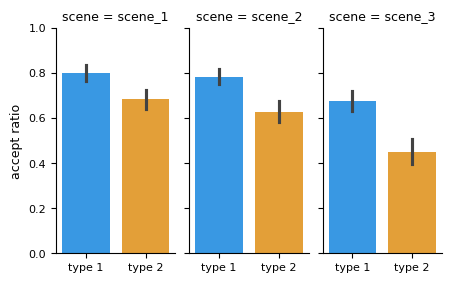

      scene driving  type  accept_mean  reject_mean  ignore_mean   n
0   scene_1    auto     1     0.816667     0.083333     0.100000  12
1   scene_1    auto     2     0.633333     0.316667     0.050000  12
2   scene_1  manual     1     0.783333     0.100000     0.116667  12
3   scene_1  manual     2     0.733333     0.166667     0.100000  12
4   scene_2    auto     1     0.816667     0.116667     0.066667  12
5   scene_2    auto     2     0.566667     0.366667     0.066667  12
6   scene_2  manual     1     0.750000     0.183333     0.066667  12
7   scene_2  manual     2     0.688889     0.230556     0.080556  12
8   scene_3    auto     1     0.783333     0.200000     0.016667  12
9   scene_3    auto     2     0.416667     0.516667     0.066667  12
10  scene_3  manual     1     0.566667     0.316667     0.116667  12
11  scene_3  manual     2     0.486111     0.347222     0.166667  12

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=24, mean=0.800, m

In [411]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

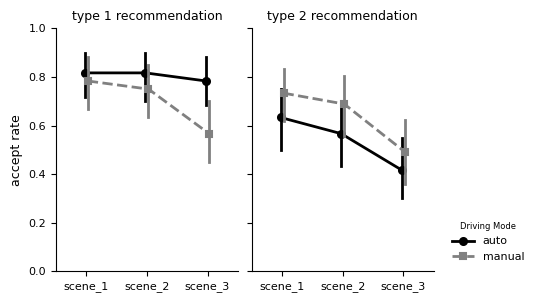

In [412]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.6,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name} recommendation")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

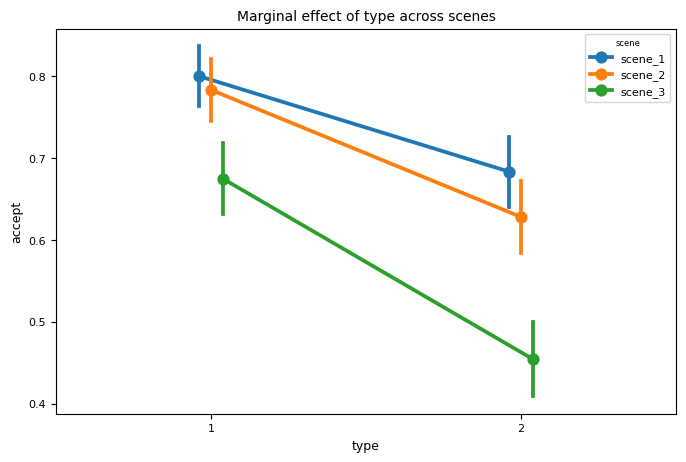

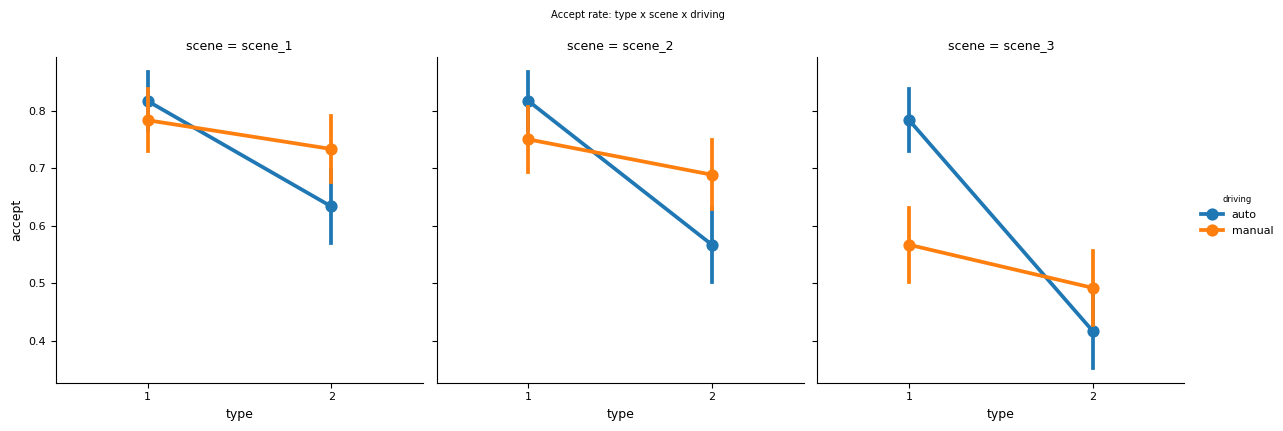

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1618/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1618/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1618/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

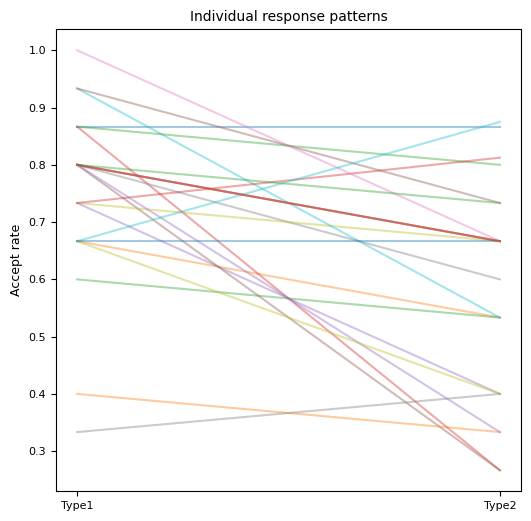

In [413]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [414]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1618/1223868461.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


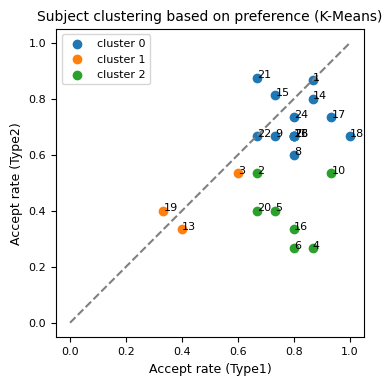

In [415]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

plt.figure(figsize=(4,4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
# plt.xticks(np.linspace(0, 1, 11))
# plt.yticks(np.linspace(0, 1, 11))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Subject clustering based on preference (K-Means)")
plt.show()

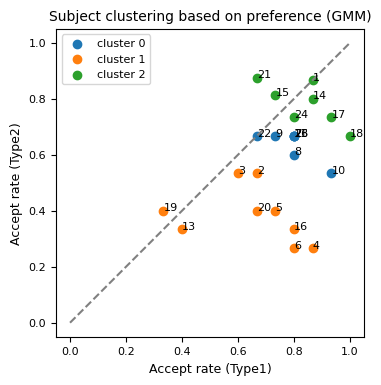

In [416]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X = pivot[["accept_type1", "accept_type2"]].values

gmm = GaussianMixture(n_components=3, random_state=42)
pivot["cluster"] = gmm.fit_predict(X)

fig, ax = plt.subplots(figsize=(4, 4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"] == c]
    ax.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

ax.set_xlabel("Accept rate (Type1)")
ax.set_ylabel("Accept rate (Type2)")
ax.set_aspect("equal", adjustable="box")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.legend()
ax.set_title("Subject clustering based on preference (GMM)")

plt.show()

In [417]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
13    0.400000  0.333333  0.066667
14    0.866667  0.800000  0.066667
15    0.733333  0.812500 -0.079167
16    0.800000  0.333333  0.466667
17    0.933333  0.733333  0.200000
18    1.000000  0.666667  0.333333
19    0.333333  0.400000 -0.066667
20    0.666667  0.400000  0.266667
21    0.666667  0.875000 -0.208333
22    0.666667  0.666667  0.000000
23    0.800000  0.666667  0.133333
24    0.800000  0.733333  0.066667
26    0.800000  0.666667  0.133333


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1618/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling

For each reaction, we aggregate trial-level features into the following groups.

---

### Meta

- `sub_id`: subject ID (`int`)
- `scene_id`: scene ID (`int`)
- `mode`: driving mode (`int`)
- `recommendation`: recommendation code (`int`, 5 digits)
- `recommendation_category`: recommendation category (`int`, 1 digit)
- `recommendation_subcategory`: recommendation subcategory (`int`, 3 digits)

---

### Prior

These variables describe the participant’s baseline tendency and behavioral state before the current recommendation.

- `subject_prior_accept_prob_subcategory`: subject-level prior probability of accepting this recommendation subcategory (`float`)
- `mean_steering_input`: mean steering input (`float`)
- `var_steering_input`: variance of steering input (`float`)
- `mean_throttle_input`: mean throttle input (`float`)
- `var_throttle_input`: variance of throttle input (`float`)

---

### Scenario

These variables describe the current recommendation and the driving context around the reaction.

- `intensity`: intensity of the recommendation (`float`)
- `coherence`: coherence of the recommendation (`float`)
- `mean_steering_input_zscore_pre2s`: mean steering input z-score in the 2 s pre-reaction window (`float`)
- `mean_throttle_input_zscore_pre2s`: mean throttle input z-score in the 2 s pre-reaction window (`float`)

---

### Reaction

These variables describe the behavioral response to the recommendation.

- `accept`: whether the recommendation was accepted (`bool`)
- `reaction_time_ms`: reaction time in milliseconds (`float`)
- `mean_steering_input_zscore_post5s`: mean steering input z-score in the 5 s post-reaction window (`float`)
- `mean_throttle_input_zscore_post5s`: mean throttle input z-score in the 5 s post-reaction window (`float`)

---

### Evaluation

These variables describe the participant’s subjective evaluation after the reaction.

- `disturbance`: perceived disturbance (`float`)
- `satisfaction`: subjective satisfaction (`float`)
- `appropriateness`: perceived appropriateness (`float`)

---

## Dynamic Modeling Goal

We build a dynamical decision model that takes **prior** and **scenario** variables as inputs to predict whether a recommendation is **accepted**.

The model is designed to capture the competition between latent **accept** and **reject** decision states over time.

---

## Modeling Assumption

We assume that the biological time constant of the decision dynamics is the same across participants.

In other words:

- the accept-state time constant is shared across subjects
- the reject-state time constant is shared across subjects

This means that individual differences are modeled mainly through:

- prior acceptance tendency
- scenario-dependent inputs
- reaction-specific context

rather than through subject-specific intrinsic time constants.


In [418]:
df_reaction = databuilder.build_per_reaction_df(
    data_dict,
    intensity_dict = stimuli_intensity_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
    # df_subject_prior=df_subject_prior,
)

# print(df_reaction["prior_mean_throttle_input"].head())

reaction_data_dict = databuilder.build_per_reaction_data_dict(df_reaction)

## 4.1 Subcategory Disturbance, Satisfaction and Appropriateness

In [419]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

df = df_reaction.copy()

df["scene_id"] = df["scene_id"].astype("category")
df["mode"] = df["mode"].astype("category")
df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")
df["sub_id"] = df["sub_id"].astype("category")

metrics = ["appropriateness", "disturbance", "satisfaction"]

In [420]:
for col in ["recommendation_subcategory", "scene_id", "mode"]+metrics:
    print(col, df[col].isna().sum(), df[col].dtype)

recommendation_subcategory 0 category
scene_id 0 category
mode 0 category
appropriateness 0 int16
disturbance 0 int16
satisfaction 0 int16


In [421]:
overall_results = []

for metric in metrics:
    formula = f"{metric} ~ C(recommendation_subcategory, Sum) * scene_id * mode"
    model_all = smf.mixedlm(
        formula,
        df,
        groups=df["sub_id"]
    ).fit(reml=False)

    print("\n" + "="*80)
    print(f"OVERALL MODEL FOR {metric}")
    print("="*80)
    print(model_all.summary())

    coef_table = pd.DataFrame({
        "term": model_all.params.index,
        "coef": model_all.params.values,
        "pval": model_all.pvalues.values
    })
    coef_table["metric"] = metric
    overall_results.append(coef_table)
    terms = [
        t for t in model_all.params.index
        if "C(recommendation_subcategory, Sum)" in t
        and ":" not in t
    ]

    hypothesis = ", ".join([f"{t} = 0" for t in terms])

    print(model_all.wald_test(hypothesis))

overall_results_df = pd.concat(overall_results, ignore_index=True)


OVERALL MODEL FOR appropriateness
                                      Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  appropriateness
No. Observations:                    722                      Method:                              ML             
No. Groups:                          24                       Scale:                               2.1074         
Min. group size:                     30                       Log-Likelihood:                      -1314.5462     
Max. group size:                     31                       Converged:                           Yes            
Mean group size:                     30.1                                                                         
------------------------------------------------------------------------------------------------------------------
                                                                        Coef.  Std.E

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, 

In [422]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# =========================================================
# 0) 基础准备
# =========================================================
df = df.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ scene_id * mode
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ scene_id * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 scene / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        scene_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "scene_min_p": scene_terms["pval"].min() if len(scene_terms) else np.nan,
            "scene_min_p_fdr": scene_terms["pval_fdr"].min() if len(scene_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) 全局模型:
#    metric ~ C(recommendation_subcategory, Sum) + scene_id + mode
#    计算每个 subcategory 相对 overall mean 的显著性
# =========================================================
def parse_sum_term_level(term):
    # e.g. C(recommendation_subcategory, Sum)[S.101] -> "101"
    if "[S." in term:
        return term.split("[S.")[-1].rstrip("]")
    return None


def cast_level_to_match_categories(level_str, categories):
    if len(categories) == 0:
        return level_str

    first = categories[0]

    try:
        if isinstance(first, (int, np.integer)):
            return int(level_str)
        elif isinstance(first, (float, np.floating)):
            return float(level_str)
        else:
            return str(level_str)
    except Exception:
        return level_str


def wald_pvalue(test_obj):
    return float(np.asarray(test_obj.pvalue).reshape(-1)[0])


def get_subcategory_vs_mean_from_global_model(model, subcat_levels):
    params = model.params.index.tolist()

    main_terms = [
        t for t in params
        if "C(recommendation_subcategory, Sum)" in t and ":" not in t
    ]

    if len(main_terms) == 0:
        raise ValueError("No main-effect sum-coded subcategory terms found in model.")

    results = []
    mapped_levels = []

    # -------- 显式显示的 levels --------
    for term in main_terms:
        lvl_raw = parse_sum_term_level(term)
        lvl = cast_level_to_match_categories(lvl_raw, subcat_levels)
        mapped_levels.append(lvl)

        # 用 wald_test，不用 t_test
        test = model.wald_test(f"{term} = 0", scalar=True)

        results.append({
            "subcategory": lvl,
            "subcat_coef": model.params[term],
            "subcat_p": wald_pvalue(test)
        })

    # -------- 最后一个隐含 level --------
    # sum coding 下最后一个 level = -(前面所有level之和)
    missing_levels = [lvl for lvl in subcat_levels if lvl not in mapped_levels]

    if len(missing_levels) == 1:
        last_level = missing_levels[0]

        expr = " + ".join(main_terms) + " = 0"
        test = model.wald_test(expr, scalar=True)

        results.append({
            "subcategory": last_level,
            "subcat_coef": -sum(model.params[t] for t in main_terms),
            "subcat_p": wald_pvalue(test)
        })

    elif len(missing_levels) > 1:
        raise ValueError(f"More than one missing level inferred: {missing_levels}")

    res_df = pd.DataFrame(results)

    res_df["subcategory"] = pd.Categorical(
        res_df["subcategory"],
        categories=subcat_levels,
        ordered=True
    )
    res_df = res_df.sort_values("subcategory").reset_index(drop=True)
    res_df["subcategory"] = res_df["subcategory"].astype(object)

    return res_df


global_subcat_effect_rows = []
global_models = {}
global_factor_tests = []

for metric in metrics:
    formula = f"{metric} ~ C(recommendation_subcategory, Sum) + scene_id + mode"

    try:
        print(f"Fitting global model for metric={metric} ...")

        model_all = smf.mixedlm(
            formula,
            df,
            groups=df["sub_id"]
        ).fit(reml=False)

        global_models[metric] = model_all

        # ---- 整体 subcategory 主效应 joint test ----
        main_terms = [
            t for t in model_all.params.index
            if "C(recommendation_subcategory, Sum)" in t and ":" not in t
        ]
        joint_expr = ", ".join([f"{t} = 0" for t in main_terms])
        joint_test = model_all.wald_test(joint_expr, scalar=True)

        global_factor_tests.append({
            "metric": metric,
            "subcategory_overall_chi2": float(np.asarray(joint_test.statistic).reshape(-1)[0]),
            "subcategory_overall_p": wald_pvalue(joint_test),
            "subcategory_df": len(main_terms)
        })

        # ---- 每个 subcategory vs overall mean ----
        subcat_effect_df = get_subcategory_vs_mean_from_global_model(
            model_all,
            subcat_levels=subcat_levels
        )
        subcat_effect_df["metric"] = metric

        global_subcat_effect_rows.append(subcat_effect_df)

    except Exception as e:
        print(f"Global model failed for metric={metric}: {e}")


if len(global_subcat_effect_rows) > 0:
    global_subcat_effect_df = pd.concat(global_subcat_effect_rows, ignore_index=True)
else:
    global_subcat_effect_df = pd.DataFrame(
        columns=["subcategory", "subcat_coef", "subcat_p", "metric"]
    )

global_factor_tests_df = pd.DataFrame(global_factor_tests)


# =========================================================
# 5) FDR for subcategory-vs-mean
# =========================================================
global_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(global_subcat_effect_df) > 0:
    for metric in metrics:
        idx = global_subcat_effect_df["metric"] == metric
        pvals = global_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = global_subcat_effect_df.index[idx].to_numpy()
            global_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================
summary_df = summary_df.merge(
    global_subcat_effect_df[
        ["subcategory", "metric", "subcat_coef", "subcat_p", "subcat_p_fdr"]
    ],
    on=["subcategory", "metric"],
    how="left"
)

summary_df = summary_df.merge(
    global_factor_tests_df,
    on="metric",
    how="left"
)

summary_df = summary_df.sort_values(["metric", "subcategory"]).reset_index(drop=True)


# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["scene_sig"] = summary_df["scene_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha


# =========================================================
# 8) 输出
# =========================================================
# print("\nglobal_factor_tests_df:")
# print(global_factor_tests_df)

# print("\nglobal_subcat_effect_df:")
# print(global_subcat_effect_df.head())

# print("\nsummary_df:")
# print(summary_df.head())

summary_df

Fitting global model for metric=appropriateness ...
Fitting global model for metric=disturbance ...
Fitting global model for metric=satisfaction ...


,subcategory,metric,scene_min_p,scene_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,subcat_coef,subcat_p,subcat_p_fdr,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,scene_sig,mode_sig,interaction_sig,subcat_vs_mean_sig,subcategory_overall_sig
0,101,appropriateness,3.751876e-01,5.620891e-01,0.227142,0.757141,0.059947,0.299735,1.322124,3.159754e-14,3.159754e-13,174.681322,6.525248e-33,9,False,False,False,True,True
1,102,appropriateness,5.491221e-02,2.238071e-01,1.000000,1.000000,0.415413,0.593447,0.961013,3.426629e-08,1.142210e-07,174.681322,6.525248e-33,9,False,False,False,True,True
2,103,appropriateness,4.395293e-01,5.620891e-01,0.360351,0.900879,0.218766,0.447805,0.599902,5.718616e-04,9.531027e-04,174.681322,6.525248e-33,9,False,False,False,True,True
3,104,appropriateness,1.319028e-01,1.943592e-01,0.051150,0.511498,0.110035,0.353993,0.461013,8.117954e-03,1.159708e-02,174.681322,6.525248e-33,9,False,False,False,True,True
4,105,appropriateness,4.269234e-06,4.269234e-05,0.808633,1.000000,0.057893,0.299735,-0.788987,5.888801e-06,1.472200e-05,174.681322,6.525248e-33,9,True,False,False,True,True
5,201,appropriateness,4.241921e-04,2.120961e-03,0.813987,1.000000,0.530148,0.662685,-0.288005,9.424215e-02,1.047135e-01,174.681322,6.525248e-33,9,True,False,False,False,True
6,202,appropriateness,1.224041e-01,1.943592e-01,0.797985,1.000000,0.395561,0.662685,-0.386209,2.658188e-02,3.322734e-02,174.681322,6.525248e-33,9,False,False,False,True,True
7,203,appropriateness,1.360514e-01,1.943592e-01,0.917239,1.000000,0.223903,0.447805,-0.747320,1.777950e-05,3.555900e-05,174.681322,6.525248e-33,9,False,False,False,True,True
8,204,appropriateness,7.859332e-02,1.943592e-01,0.104934,0.524669,0.141597,0.353993,-1.108432,1.958190e-10,9.790950e-10,174.681322,6.525248e-33,9,False,False,False,True,True
9,205,appropriateness,2.264361e-02,7.547871e-02,0.906258,1.000000,0.132498,0.447805,-0.025098,8.854112e-01,8.854112e-01,174.681322,6.525248e-33,9,False,False,False,False,True


In [423]:
from itertools import combinations
from scipy.stats import ttest_rel

pairwise_rows = []

for metric in metrics:
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    wide = agg.pivot(index="sub_id", columns="recommendation_subcategory", values=metric)

    for a, b in combinations(wide.columns, 2):
        paired = wide[[a, b]].dropna()
        if len(paired) >= 2:
            stat, pval = ttest_rel(paired[a], paired[b])
            pairwise_rows.append({
                "metric": metric,
                "subcat_a": a,
                "subcat_b": b,
                "n_subjects": len(paired),
                "mean_a": paired[a].mean(),
                "mean_b": paired[b].mean(),
                "mean_diff": (paired[a] - paired[b]).mean(),
                "pval": pval
            })

pairwise_df = pd.DataFrame(pairwise_rows)

# FDR per metric
pairwise_df["pval_fdr"] = np.nan
for metric in metrics:
    idx = pairwise_df["metric"] == metric
    if idx.sum() > 0:
        pairwise_df.loc[idx, "pval_fdr"] = multipletests(
            pairwise_df.loc[idx, "pval"],
            method="fdr_bh"
        )[1]

pairwise_df = pairwise_df.sort_values(["metric", "pval_fdr"])
pairwise_df.head(20)

,metric,subcat_a,subcat_b,n_subjects,mean_a,mean_b,mean_diff,pval,pval_fdr
3,appropriateness,101,105,24,6.458333,4.347222,2.111111,1.163566e-07,0.000002
6,appropriateness,101,203,24,6.458333,4.388889,2.069444,8.041874e-08,0.000002
7,appropriateness,101,204,24,6.458333,4.027778,2.430556,1.472679e-07,0.000002
5,appropriateness,101,202,24,6.458333,4.750000,1.708333,2.041035e-06,0.000023
4,appropriateness,101,201,24,6.458333,4.829861,1.628472,5.282305e-06,0.000048
15,appropriateness,102,204,24,6.097222,4.027778,2.069444,1.591541e-05,0.000119
14,appropriateness,102,203,24,6.097222,4.388889,1.708333,7.332097e-05,0.000471
11,appropriateness,102,105,24,6.097222,4.347222,1.750000,1.103179e-04,0.000607
22,appropriateness,103,204,24,5.736111,4.027778,1.708333,1.213913e-04,0.000607
8,appropriateness,101,205,24,6.458333,5.111111,1.347222,1.532245e-04,0.000690


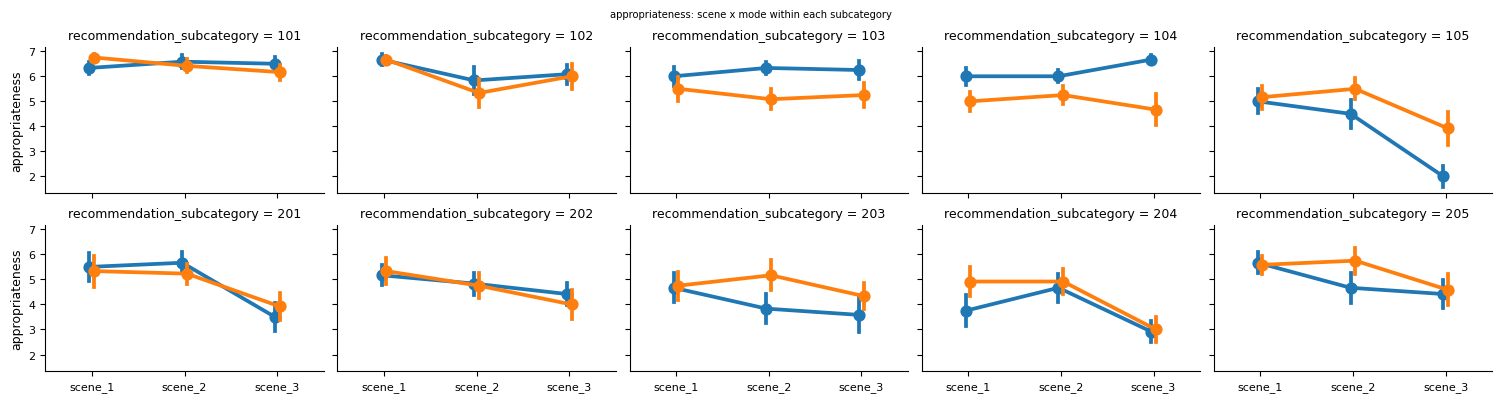

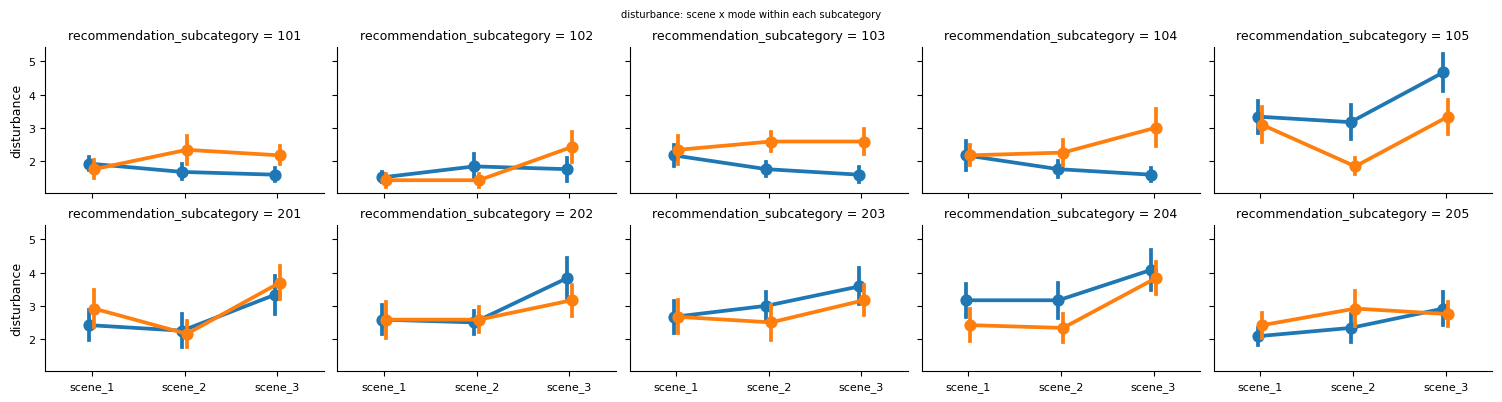

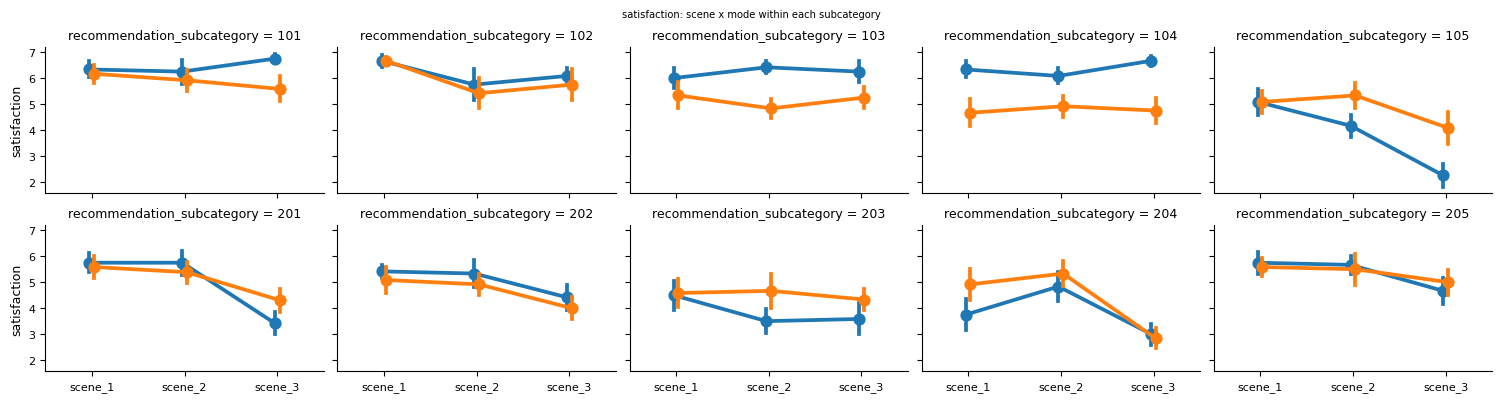

In [424]:
for metric in metrics:
    g = sns.catplot(
        data=df,
        x="scene_id",
        y=metric,
        hue="mode",
        col="recommendation_subcategory",
        kind="point",
        errorbar="se",
        dodge=True,
        col_wrap=5,
        height=2,
        aspect=1.5,
        legend=False,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"{metric}: scene x mode within each subcategory")
    for ax in g.axes.flat:
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

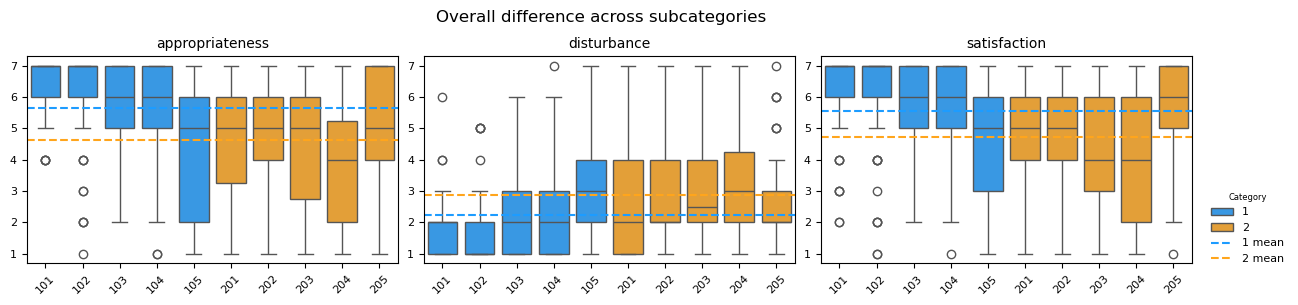

In [425]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=df,
        x="recommendation_subcategory",
        y=metric,
        hue="recommendation_category",
        palette=type_palette,
        ax=ax
    )

    # ===== type-level mean =====
    type_means = df.groupby("recommendation_category")[metric].mean()

    for t, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            linestyle="--",
            linewidth=1.5,
            color=type_palette.get(t, "gray"),
            alpha=1.0,
            label=f"{t} mean"
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

fig.suptitle("Overall difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles, labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

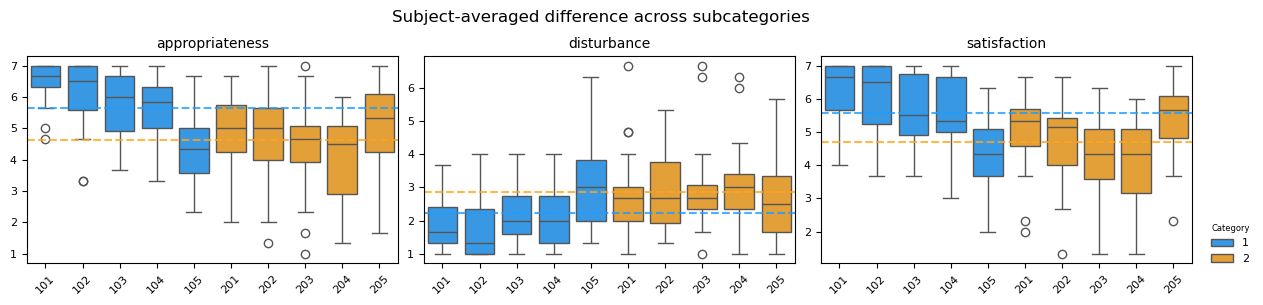

In [426]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

    # type/category 的整体均值
    type_means = agg.groupby("category")[metric].mean()

    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=agg,
        x="recommendation_subcategory",
        y=metric,
        hue="category",
        palette=type_palette,
        ax=ax
    )

    # 画不同 type 的均值横线
    for cat, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            color=type_palette.get(cat, "gray"),
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

fig.suptitle("Subject-averaged difference across subcategories", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles,
    labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

In [427]:
df_reaction[["appropriateness", "disturbance", "satisfaction"]].corr()

,appropriateness,disturbance,satisfaction
appropriateness,1.000000,-0.613398,0.865251
disturbance,-0.613398,1.000000,-0.642541
satisfaction,0.865251,-0.642541,1.000000


In [428]:
df_reaction[["disturbance", "intensity", "mean_throttle_pre2s"]].corr()

,disturbance,intensity,mean_throttle_pre2s
disturbance,1.000000,0.092880,-0.014856
intensity,0.092880,1.000000,-0.010134
mean_throttle_pre2s,-0.014856,-0.010134,1.000000


## 4.2 Baseline Model: logistic regression and svm

In [429]:
features = [
    "subject_prior_accept_prob_subcategory",
    "intensity",
    "coherence",
    "var_throttle_pre2s",
    "mean_throttle_pre2s",
    "car_density",
    "time_pressure",
    "mode",
    # "appropriateness",
    # "disturbance",
    # "satisfaction",
]

target = "accept"

In [430]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = df_reaction[features].copy()
y = df_reaction[target].astype(int)

X["time_pressure"] = X["time_pressure"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.7310344827586207
AUC: 0.7181056701030928
              precision    recall  f1-score   support

           0       0.67      0.38      0.48        48
           1       0.75      0.91      0.82        97

    accuracy                           0.73       145
   macro avg       0.71      0.64      0.65       145
weighted avg       0.72      0.73      0.71       145



In [431]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, kernel="rbf"))
])

pipe_svm.fit(X_train, y_train)

y_pred_svm = pipe_svm.predict(X_test)
y_prob_svm = pipe_svm.predict_proba(X_test)[:, 1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM AUC:", roc_auc_score(y_test, y_prob_svm))

SVM Accuracy: 0.6758620689655173
SVM AUC: 0.7200386597938144


In [432]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy))

Dummy Accuracy: 0.6689655172413793


In [433]:
coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=features).sort_values()

print(feature_importance)

mean_throttle_pre2s                     -0.544365
time_pressure                           -0.333509
car_density                             -0.065759
intensity                               -0.035193
coherence                                0.000000
mode                                     0.031920
var_throttle_pre2s                       0.368072
subject_prior_accept_prob_subcategory    0.945439
dtype: float64


## 4.3 1d Dynamics Simulation

The latent decision state `x` evolves as:

`change in x = leak + nonlinear term + input drive + noise`

More specifically:

`dx/dt = -lam * x + a * tanh(gain * (x - theta_dyn)) + u + noise`

where:

- `lam`: how strongly the state decays back
- `a`: strength of nonlinear attraction
- `gain`: steepness of the nonlinearity
- `theta_dyn`: center of the nonlinear curve
- `u`: evidence / pressure input
- `noise`: random fluctuation

Initial state:

`x0 = kappa * logit(p0)`

Decision readout:

`p_accept = sigmoid(x_final - theta_readout)`

Important:

- `theta_dyn` is part of the dynamics
- `theta_readout` is the final decision threshold
- nullcline means `dx/dt = 0`

In [519]:
dummy_row = pd.Series({

    # ---------------- meta ----------------
    "sub_id": 0,
    "scene_id": "scene_1",
    "mode": "manual",
    "trial_id": 0,
    "recommendation": "dummy recommendation",
    "recommendation_category": 1,
    "recommendation_subcategory": 101,

    # ---------------- prior ----------------
    "subject_prior_accept_prob_subcategory": 0.5,
    "prior_mean_throttle_input": 0.0,
    "prior_var_throttle_input": 0.0,

    # ---------------- scenario ----------------
    "intensity": 0.0,
    "coherence": 1.0,
    "mean_throttle_input_zscore_pre2s": 0.0,
    "mean_throttle_pre2s": 0.0,
    "var_throttle_pre2s": 0.0,
    "car_density": 0.0,
    "time_pressure": 0,

    # ---------------- reaction ----------------
    "reaction": "ignore",
    "accept": False,
    "reaction_time_ms": np.nan,
    "mean_throttle_input_zscore_post5s": 0.0,
    "mean_throttle_post5s": 0.0,
    "var_throttle_post5s": 0.0,

    # ---------------- evaluation ----------------
    "appropriateness": 0.0,
    "disturbance": 0.0,
    "satisfaction": 0.0,

    # ---------------- bookkeeping ----------------
    "reaction__time_ms": 0.0,
    "trigger__time_ms": 0.0,
})

scene_id :scene_1, mode: manual, subcatgory: 101
===== Single Trial Demo (1D) =====
model = nonlinear_sigmoid
prior p0 = 0.500
x0 = -0.001
u = 0.950
lam_eff = 1.000
sigma_eff = 0.040
gain_eff = 2.500
theta_dyn = 0.000
theta_readout = 0.000
x_final = 3.362
p_accept = 0.966
predicted accept = 1
fixed points:
  x* = -1.369, stable, slope=-0.617
  x* = -0.575, unstable, slope=0.939
  x* = 3.424, stable, slope=-0.998


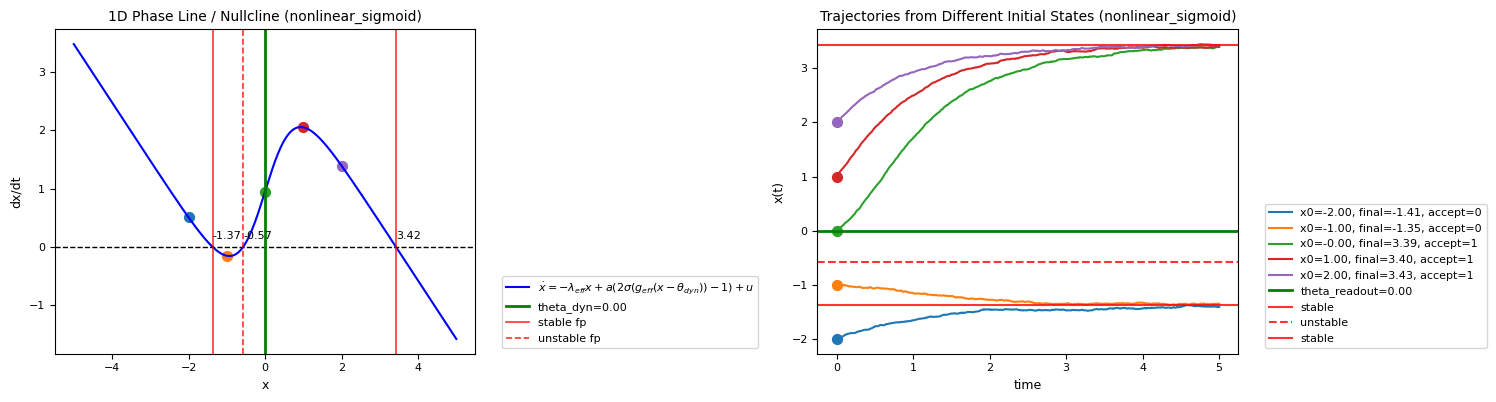

In [435]:
# row = df_reaction.iloc[100]
row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

result = oneddynamics.run_single_trial_demo(
    row,
    model="nonlinear_sigmoid",
    beta_c=1.0,
    beta_i=1.0,
    beta_ci=0.5,

    gamma_throttle=0.3,
    gamma_density=0.05,
    gamma_time=0.3,
    gamma_mode=0.05,

    kappa=0.5,
    lam=1.0,
    a=2.5,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

In [450]:
df_sim = oneddynamics.simulate_dataframe_decisions(
    df_reaction,
    model="nonlinear_sigmoid",
    beta_c=1.0,
    beta_i=1.0,
    beta_ci=0.5,

    gamma_throttle=0.3,
    gamma_density=0.05,
    gamma_time=0.3,
    gamma_mode=0.05,

    kappa=1.5,
    lam=1.0,
    a=2.5,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

print(df_sim.head())
print((df_sim["accept_pred"] == df_sim["accept_true"]).mean())

   idx        x0         u  lam_eff  sigma_eff  gain_eff   x_final  \
0    0  2.580019  0.247273      1.0       0.04       2.5  2.213269   
1    1  2.616161  0.278182      1.0       0.04       2.5  2.372949   
2    2  2.327769  0.567273      1.0       0.04       2.5  2.976895   
3    3  2.839361  0.460000      1.0       0.04       2.5  2.792494   
4    4  2.973214  0.409091      1.0       0.04       2.5  2.766847   

   p_accept_pred  accept_pred  n_fixed_points            fixed_points  \
0       0.901435            1               3  -1.7274,-0.1649,2.2611   
1       0.914741            1               3  -1.8005,-0.1721,2.3928   
2       0.951519            1               3  -1.7918,-0.3015,2.9777   
3       0.942269            1               3  -1.8612,-0.2464,2.8218   
4       0.940858            1               3  -1.8777,-0.2225,2.7331   

   accept_true  
0            1  
1            1  
2            1  
3            1  
4            1  
0.7229916897506925


In [437]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim["accept_true"], df_sim["accept_pred"])
print(cm)

[[ 86 152]
 [ 49 435]]


In [438]:
corr_df = oneddynamics.build_dynamical_correction_features(df)
df_model = df.join(corr_df.set_index("idx"), how="left")

In [439]:
df_model[["xT_nonlinear", "accept"]].corr()

,xT_nonlinear,accept
xT_nonlinear,1.000000,0.314731
accept,0.314731,1.000000


In [440]:
X_base = df_model[features]
y = df_model["accept"].astype(int)

dynamics_feature = features + ["delta_nonlinear_extra"]
X_corr = df_model[dynamics_feature]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = X_corr
y = df_reaction[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=dynamics_feature).sort_values()

print(feature_importance)

Accuracy: 0.7103448275862069
AUC: 0.7178908934707904
              precision    recall  f1-score   support

           0       0.64      0.29      0.40        48
           1       0.72      0.92      0.81        97

    accuracy                           0.71       145
   macro avg       0.68      0.60      0.60       145
weighted avg       0.69      0.71      0.67       145

mean_throttle_pre2s                     -0.530909
time_pressure                           -0.343298
delta_nonlinear_extra                   -0.290827
car_density                             -0.079973
intensity                               -0.006163
coherence                                0.000000
mode                                     0.011997
var_throttle_pre2s                       0.347909
subject_prior_accept_prob_subcategory    1.210952
dtype: float64


## 4.4 2d dynamics

The latent decision states \(x\) (accept) and \(y\) (reject) evolve as:

`change in state = leak + nonlinear term + input drive + noise`

---

### Dynamics

For accept state:

`dx/dt = -lam_x * x + phi_x(x + w_xy * y) + f_x + noise_x`

For reject state:

`dy/dt = -lam_y * y + phi_y(y + w_yx * x) + f_y + noise_y`

---

### Nonlinearity (Cubic)

`phi(z) = z - a * z^3`

- creates saturation and multi-stability  
- allows curved nullclines and attractor competition  

---

### Inputs (Drives)

Accept drive:

`f_x = alpha_prior * logit(p0)
     + alpha_coherence * coherence
     + alpha_intensity * intensity
     + alpha_ci * coherence * intensity
     + alpha_density * car_density`

Reject drive:

`f_y = beta_pressure * effective_pressure
     + beta_density * car_density
     + beta_time_pressure * time_pressure
     + beta_low_coherence * (1 - coherence)
     + beta_prior * (-logit(p0))`

---

### Context Modulation

`effective_pressure = pressure`

- reduced in auto mode via `auto_pressure_reduction`
- scaled by:
  - `density_pressure_gain`
  - `time_pressure_gain`

---

### Initial State

`x0 = kappa * logit(p0)`  
`y0 = -kappa * logit(p0)`

---

### Decision Readout

`decision = accept if (x_final - y_final) > theta`

or probabilistic:

`p_accept = sigmoid(x_final - y_final - theta)`

---

### Key Parameters

- `lam_x, lam_y`: decay (leak)
- `w_xy, w_yx`: cross-coupling (competition / excitation)
- `a`: cubic nonlinearity strength
- `sigma_x, sigma_y`: noise level
- `theta`: decision threshold

---

### Important

- competition is **implicit via coupling (w_xy, w_yx)**  
- nonlinearity shapes **attractor landscape**  
- prior enters both:
  - initial condition  
  - asymmetric drives (f_x vs f_y)  
- system outcome depends on **fixed points + trajectory**

---

### Nullcline

Nullcline is defined as:

`dx/dt = 0` and `dy/dt = 0`

Their intersection gives **fixed points** (decision attractors).


scene_id :scene_1, mode: 1, subcatgory: 101
===== Single Trial Demo (2D unified nonlinear) =====
prior_accept_prob = 0.867
coherence = 0.000
intensity = 0.238
stim_raw = 0.238
stim_on_x = 0.850
stim_on_y = 0.850
effective_pressure = 0.020
accept drive f_x = 0.238
reject drive f_y = 0.026
initial state = (0.380, -0.380)
fixed point = (0.567, -1.383)
final state = (0.551, -1.332)
final diff x-y = 1.884
p_accept = 0.868
accept_pred = 1


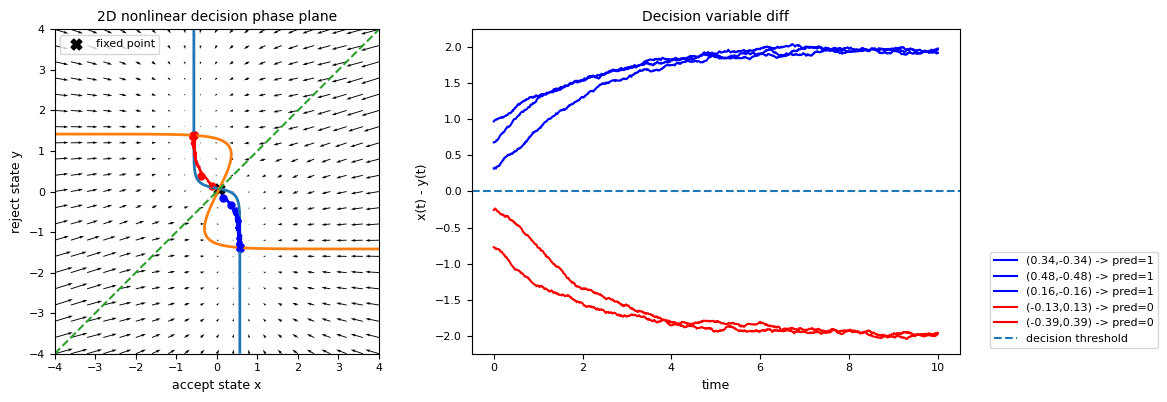

In [552]:
row = df_reaction.iloc[1]
# row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

demo = twoddynamics.run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=0.05,
    density_pressure_gain=0.1,
    time_pressure_gain=0.3,

    alpha_coherence=1.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.3,
    beta_density=0.1,
    beta_time_pressure=0.25,

    k_init=1.0,
    lam_x=1.5,
    lam_y=0.6,
    w_xy=3.0,
    w_yx=1.0,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=True,
)

In [509]:
df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

df_sim = twoddynamics.simulate_dataframe_2d(
    df_reaction,
    
    auto_pressure_reduction=0.05,
    density_pressure_gain=0.1,
    time_pressure_gain=0.3,

    alpha_coherence=1.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.3,
    beta_density=0.1,
    beta_time_pressure=0.25,

    k_init=1.0,
    lam_x=1.5,
    lam_y=0.6,
    w_xy=3.0,
    w_yx=1.0,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=True,
)
# print(df_sim.head())

valid = df_sim.dropna(subset=["accept_true"])
acc = (valid["accept_pred"] == valid["accept_true"]).mean()
print("original acceptance rate =", valid["accept_true"].mean())
print("accuracy =", acc)

original acceptance rate = 0.6703601108033241
accuracy = 0.7285318559556787


In [443]:
# from scipy.optimize import differential_evolution
# from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
# import numpy as np

# param_names = [
#     "w_xy", "w_yx", "lam_x", "lam_y", "gain_x", "gain_y"
# ]

# bounds = [
#     (0.5, 4.0),   # w_xy
#     (0.5, 4.0),   # w_yx
#     (0.6, 1.6),   # lam_x
#     (0.6, 1.6),   # lam_y
#     (1.0, 2.0),   # gain_x
#     (1.0, 2.0),   # gain_y
# ]

# fixed_params = {
#     "auto_pressure_reduction": 0.05,
#     "density_pressure_gain": 0.1,
#     "time_pressure_gain": 0.25,

#     "alpha_coherence": 1.0,
#     "alpha_intensity": 1.0,
#     "alpha_ci": 0.5,

#     "beta_pressure": 0.1,
#     "beta_density": 0.1,
#     "beta_time_pressure": 0.25,

#     "k_init": 2.5,
#     "sigma_x": 0.04,
#     "sigma_y": 0.04,
#     "T": 10.0,
#     "decision_threshold": 0.0,
# }

# def objective(vec):
#     params = dict(fixed_params)
#     for k, v in zip(param_names, vec):
#         params[k] = float(v)

#     df_sim = twoddynamics.simulate_dataframe_2d(df_reaction, **params)
#     valid = df_sim.dropna(subset=["accept_true", "accept_pred"]).copy()

#     if len(valid) == 0:
#         return 1e6

#     y_true = valid["accept_true"].astype(int).to_numpy()
#     y_prob = np.clip(valid["accept_pred"].astype(float).to_numpy(), 1e-6, 1 - 1e-6)
#     y_pred = (y_prob >= 0.5).astype(int)

#     acc = accuracy_score(y_true, y_pred)

#     try:
#         auc = roc_auc_score(y_true, y_prob)
#     except ValueError:
#         auc = 0.5

#     try:
#         nll = log_loss(y_true, y_prob)
#     except ValueError:
#         nll = 10.0

#     score = acc + auc - 0.2 * nll
#     return -score

# result = differential_evolution(
#     objective,
#     bounds=bounds,
#     seed=123,
#     maxiter=30,
#     popsize=10,
#     polish=True,
#     disp=True,
# )

# best_vec = result.x
# best_params = dict(fixed_params)
# for k, v in zip(param_names, best_vec):
#     best_params[k] = float(v)

# print(best_params)
# print("best objective =", -result.fun)

In [444]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print("true accept rate =", valid["accept_true"].mean())
print("pred accept rate =", valid["accept_pred"].mean())

cm = pd.crosstab(
    valid["accept_true"],
    valid["accept_pred"],
    rownames=["true"],
    colnames=["pred"],
    dropna=False
)
print(cm)

true accept rate = 0.6703601108033241
pred accept rate = 0.775623268698061
pred    0    1
true          
0     101  137
1      61  423


In [445]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print(valid[["f_x", "f_y"]].describe())
print("mean f_x =", valid["f_x"].mean())
print("mean f_y =", valid["f_y"].mean())
print("mean f_x - f_y =", (valid["f_x"] - valid["f_y"]).mean())

              f_x         f_y
count  722.000000  722.000000
mean     0.324880    0.157860
std      0.122583    0.147790
min      0.000000    0.022000
25%      0.207273    0.022000
50%      0.369091    0.088000
75%      0.407273    0.363000
max      0.527273    0.363479
mean f_x = 0.3248803827751196
mean f_y = 0.1578597147895135
mean f_x - f_y = 0.16702066798560608
